<a href="https://colab.research.google.com/github/Jirtus-sanasam/MLP-Diabetes/blob/main/AfterGAFeature_selection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv('/content/diabetes_data2.csv')
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
cols_invalid_zero = ['Glucose','BloodPressure',
                     'SkinThickness','Insulin','BMI','Age']

df[cols_invalid_zero] = df[cols_invalid_zero].replace(0, np.nan)

In [6]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

imputer = IterativeImputer(random_state=42, max_iter=10)
df[cols_invalid_zero] = imputer.fit_transform(df[cols_invalid_zero])

In [7]:
# Interactions
df['Glucose_BMI']           = df['Glucose'] * df['BMI']
df['Glucose_Insulin']       = df['Glucose'] * df['Insulin']
df['BMI_Age']               = df['BMI'] * df['Age']
df['Insulin_SkinThickness'] = df['Insulin'] * df['SkinThickness']

# Ratios
df['Glucose_Insulin_Ratio'] = df['Glucose'] / (df['Insulin'] + 1e-6)
df['BMI_Age_Ratio']         = df['BMI'] / (df['Age'] + 1e-6)

# Polynomial
df['Glucose_sq'] = df['Glucose'] ** 2
df['BMI_sq']     = df['BMI'] ** 2
df['Age_sq']     = df['Age'] ** 2
# Age bins (one-hot)
df['Age_Group'] = pd.cut(df['Age'],
    bins=[0,30,45,60,100],
    labels=['Young','Middle','Senior','Elderly']).astype(str)
df = pd.get_dummies(df, columns=['Age_Group'], drop_first=True)

# BMI category (one-hot)
df['BMI_Category'] = pd.cut(df['BMI'],
    bins=[0,18.5,24.9,29.9,100],
    labels=['Underweight','Normal','Overweight','Obese']).astype(str)
df = pd.get_dummies(df, columns=['BMI_Category'], drop_first=True)
# Glucose level (one-hot)
df['Glucose_Level'] = pd.cut(df['Glucose'],
    bins=[0,99,125,300],
    labels=['Normal','Prediabetes','Diabetes']).astype(str)
df = pd.get_dummies(df, columns=['Glucose_Level'], drop_first=True)

# HOMA-IR proxy
df['HOMA_IR'] = (df['Glucose'] * df['Insulin']) / 405

# High pregnancies flag
df['High_Pregnancies'] = (df['Pregnancies'] > 3).astype(int)

# Log transforms
df['Log_Insulin']                  = np.log1p(df['Insulin'])
df['Log_DiabetesPedigreeFunction'] = np.log1p(df['DiabetesPedigreeFunction'])
# Composite risk score
df['Risk_Score'] = (
    (df['Glucose'] / 100) + (df['BMI'] / 25) +
    (df['Age'] / 50) + df['DiabetesPedigreeFunction']
)
print("Features after engineering:", df.shape[1] - 1)

Features after engineering: 30


In [8]:
from sklearn.impute import SimpleImputer

X = df.drop('Outcome', axis=1)
Y = df['Outcome']

imputer_final = SimpleImputer(strategy='mean')
X = pd.DataFrame(imputer_final.fit_transform(X), columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (614, 30), Test: (154, 30)


In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

GA_POP_SIZE      = 30
GA_N_GENERATIONS = 20
GA_MUTATION_RATE = 0.02
GA_TOURNAMENT_K  = 3
GA_CV_FOLDS      = 5
GA_MIN_FEATURES  = 5
GA_RANDOM_STATE  = 42

np.random.seed(GA_RANDOM_STATE)
n_features    = X_train.shape[1]
feature_names = np.array(X_train.columns.tolist())
def fitness(chromosome, X_tr, y_tr):
    selected = chromosome.astype(bool)
    if selected.sum() < GA_MIN_FEATURES:
        return 0.0   # penalise near-empty subsets
    clf = RandomForestClassifier(
        n_estimators=50, max_depth=6,
        random_state=GA_RANDOM_STATE, n_jobs=-1)
    scores = cross_val_score(
        clf, X_tr[:, selected], y_tr,
        cv=GA_CV_FOLDS, scoring='roc_auc')
    return scores.mean()

def tournament_select(population, fitnesses, k=GA_TOURNAMENT_K):
    idx  = np.random.choice(len(population), k, replace=False)
    best = idx[np.argmax(fitnesses[idx])]
    return population[best].copy()

def crossover(p1, p2):
    pt = np.random.randint(1, len(p1))
    return (np.concatenate([p1[:pt], p2[pt:]]),
            np.concatenate([p2[:pt], p1[pt:]]))

def mutate(chromosome, rate=GA_MUTATION_RATE):
    mask = np.random.rand(len(chromosome)) < rate
    chromosome[mask] ^= 1
    return chromosome

In [11]:
# Initialise population
population = np.random.randint(0, 2, size=(GA_POP_SIZE, n_features))
for i in range(GA_POP_SIZE):
    if population[i].sum() < GA_MIN_FEATURES:
        population[i][np.random.choice(
            n_features, GA_MIN_FEATURES, replace=False)] = 1

X_train_arr = X_train.values
y_train_arr = y_train.values

best_chromosome = None
best_fitness    = -np.inf
generation_best = []
generation_avg  = []
print("Starting Genetic Algorithm Feature Selection...")
print(f"Pop: {GA_POP_SIZE}  Generations: {GA_N_GENERATIONS}  Features: {n_features}")
print("-" * 65)

for gen in range(GA_N_GENERATIONS):
    fitnesses = np.array([fitness(c, X_train_arr, y_train_arr)
                          for c in population])

    gen_best_idx = np.argmax(fitnesses)
    gen_best_fit = fitnesses[gen_best_idx]
    gen_avg_fit  = fitnesses.mean()
    generation_best.append(gen_best_fit)
    generation_avg.append(gen_avg_fit)
    if gen_best_fit > best_fitness:
        best_fitness    = gen_best_fit
        best_chromosome = population[gen_best_idx].copy()

    print(f"Gen {gen+1:>3}/{GA_N_GENERATIONS}  "
          f"Best AUC: {gen_best_fit:.4f}  "
          f"Avg AUC: {gen_avg_fit:.4f}  "
          f"Features: {best_chromosome.sum()}")
        # Elitism + breed new generation
    new_pop = [population[gen_best_idx].copy()]
    while len(new_pop) < GA_POP_SIZE:
        p1 = tournament_select(population, fitnesses)
        p2 = tournament_select(population, fitnesses)
        c1, c2 = crossover(p1, p2)
        new_pop.append(mutate(c1))
        if len(new_pop) < GA_POP_SIZE:
            new_pop.append(mutate(c2))
    population = np.array(new_pop)

print("-" * 65)
print(f"Best ROC-AUC (CV): {best_fitness:.4f}")
selected_features = feature_names[best_chromosome.astype(bool)]
print(f"Selected: {len(selected_features)} / {n_features} features")
print(list(selected_features))

Starting Genetic Algorithm Feature Selection...
Pop: 30  Generations: 20  Features: 30
-----------------------------------------------------------------
Gen   1/20  Best AUC: 0.8422  Avg AUC: 0.8311  Features: 13
Gen   2/20  Best AUC: 0.8457  Avg AUC: 0.8356  Features: 12
Gen   3/20  Best AUC: 0.8458  Avg AUC: 0.8380  Features: 13
Gen   4/20  Best AUC: 0.8461  Avg AUC: 0.8376  Features: 12
Gen   5/20  Best AUC: 0.8461  Avg AUC: 0.8388  Features: 12
Gen   6/20  Best AUC: 0.8461  Avg AUC: 0.8403  Features: 12
Gen   7/20  Best AUC: 0.8465  Avg AUC: 0.8407  Features: 15
Gen   8/20  Best AUC: 0.8465  Avg AUC: 0.8402  Features: 15
Gen   9/20  Best AUC: 0.8465  Avg AUC: 0.8402  Features: 15
Gen  10/20  Best AUC: 0.8465  Avg AUC: 0.8423  Features: 15
Gen  11/20  Best AUC: 0.8465  Avg AUC: 0.8421  Features: 15
Gen  12/20  Best AUC: 0.8465  Avg AUC: 0.8417  Features: 15
Gen  13/20  Best AUC: 0.8490  Avg AUC: 0.8419  Features: 14
Gen  14/20  Best AUC: 0.8490  Avg AUC: 0.8416  Features: 14
Gen  15

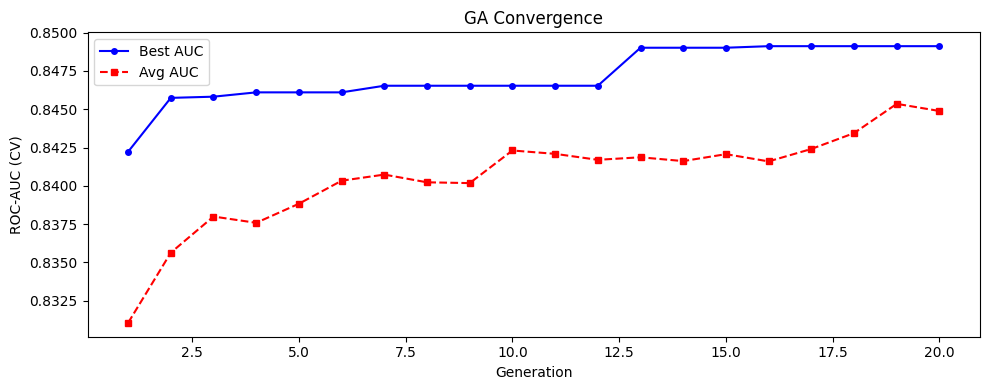

X_train after GA: (614, 14)
X_test  after GA: (154, 14)


In [12]:
# Convergence plot
plt.figure(figsize=(10, 4))
plt.plot(range(1, GA_N_GENERATIONS+1), generation_best,
         'b-o', markersize=4, label='Best AUC')
plt.plot(range(1, GA_N_GENERATIONS+1), generation_avg,
         'r--s', markersize=4, label='Avg AUC')
plt.xlabel('Generation')
plt.ylabel('ROC-AUC (CV)')
plt.title('GA Convergence')
plt.legend()
plt.tight_layout()
plt.show()

# Apply selection
X_train_ga = X_train[selected_features]
X_test_ga  = X_test[selected_features]
print(f"X_train after GA: {X_train_ga.shape}")
print(f"X_test  after GA: {X_test_ga.shape}")

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_ga)
X_test_scaled  = scaler.transform(X_test_ga)

In [14]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(
    X_train_scaled, y_train)

unique, counts = np.unique(y_train_balanced, return_counts=True)
print("After SMOTE:", dict(zip(unique, counts)))

After SMOTE: {np.int64(0): np.int64(400), np.int64(1): np.int64(400)}


In [15]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout, Input
from tensorflow.keras.regularizers import l2

tf.random.set_seed(42)
input_dim = X_train_balanced.shape[1]

model = Sequential([
    Input(shape=(input_dim,)),
    Dense(512, activation='relu', kernel_regularizer=l2(1e-4)),
    BatchNormalization(), Dropout(0.4),

    Dense(512, activation='relu', kernel_regularizer=l2(1e-4)),
    BatchNormalization(), Dropout(0.4),
        Dense(256, activation='relu', kernel_regularizer=l2(1e-4)),
    BatchNormalization(), Dropout(0.35),

    Dense(256, activation='relu', kernel_regularizer=l2(1e-4)),
    BatchNormalization(), Dropout(0.35),

    Dense(128, activation='relu', kernel_regularizer=l2(1e-4)),
    BatchNormalization(), Dropout(0.3),

    Dense(128, activation='relu', kernel_regularizer=l2(1e-4)),
    BatchNormalization(), Dropout(0.3),

    Dense(64, activation='relu', kernel_regularizer=l2(1e-4)),
    BatchNormalization(), Dropout(0.25),

    Dense(32, activation='relu', kernel_regularizer=l2(1e-4)),
    BatchNormalization(), Dropout(0.2),
        Dense(1, activation='sigmoid')
], name='DNN_Diabetes_GA')

model.summary()

Model: "DNN_Diabetes_GA"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │         7,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 534,785 (2.04 MB)

 Trainable params: 531,009 (2.03 MB)

 Non-trainable params: 3,776 (14.75 KB)

In [16]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

model.compile(optimizer=Adam(learning_rate=1e-3),
              loss='binary_crossentropy',
              metrics=['accuracy'])

callbacks = [
    EarlyStopping(monitor='val_loss', patience=20,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=8, min_lr=1e-6, verbose=1)
]

history = model.fit(
    X_train_balanced, y_train_balanced,
    validation_data=(X_test_scaled, y_test),
    epochs=200, batch_size=32,
    callbacks=callbacks, verbose=1
)

Epoch 1/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - accuracy: 0.5700 - loss: 0.9223 - val_accuracy: 0.7013 - val_loss: 0.8364 - learning_rate: 0.0010
Epoch 2/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6425 - loss: 0.8366 - val_accuracy: 0.6688 - val_loss: 0.8183 - learning_rate: 0.0010
Epoch 3/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6913 - loss: 0.7821 - val_accuracy: 0.6688 - val_loss: 0.8064 - learning_rate: 0.0010
Epoch 4/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7175 - loss: 0.7509 - val_accuracy: 0.7078 - val_loss: 0.8019 - learning_rate: 0.0010
Epoch 5/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7375 - loss: 0.6995 - val_accuracy: 0.6558 - val_loss: 0.7975 - learning_rate: 0.0010
Epoch 6/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7412 - loss: 0.6916 - val_accuracy: 0.6169 - val_loss: 0.8180 - learning_rate: 0.0010
Epoch 7/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7262 - loss: 0.6970 - 

In [17]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report
)

y_prob = model.predict(X_test_scaled).ravel()
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
best_idx    = np.argmax(tpr - fpr)
best_thresh = thresholds[best_idx]
y_pred      = (y_prob >= best_thresh).astype(int)

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step


In [18]:
print(f"Optimal threshold: {best_thresh:.4f}")
print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision : {precision_score(y_test, y_pred):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_prob):.4f}")
print(classification_report(y_test, y_pred,
      target_names=['No Diabetes','Diabetes']))

Optimal threshold: 0.5039
Accuracy  : 0.7792
Precision : 0.6429
Recall    : 0.8333
F1 Score  : 0.7258
ROC-AUC   : 0.8337
              precision    recall  f1-score   support

 No Diabetes       0.89      0.75      0.82       100
    Diabetes       0.64      0.83      0.73        54

    accuracy                           0.78       154
   macro avg       0.77      0.79      0.77       154
weighted avg       0.81      0.78      0.78       154

